# Bài 1:Biểu diễn dữ liệu thành ma trận & độ tương đồng.
* Lựa chọn Text để biểu diễn. 

In [1]:
import numpy as np 
sentences=[
    "I love HCMUT a little",
    "I love you very much",
    "Linear Algebra is the foundation of AI",
    "Machine Learning is very important",
    "MLIoT summer course is the best",
    "This is my homework of the first lesson",
    "I like the cat very much",
    "I hate the dog a lot",
    "I like you very much"
] #đây là 9 câu ngẫu nhiên làm dữ liệu
vocab = sorted ({w for s in sentences for w in s.lower ().split()}) #tạo từ điển chứa tất cả từ
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in sentences]) #số câu và số từ của data
print (X.shape) #kích thước ma trận(8 câu, 28 từ)
print (X) #ma trận 

(9, 32)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  1. 0. 0. 0. 0. 0. 1. 1.]
 [0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 1. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 1. 1.]]


* Khi ta print X.shape thì sẽ in ra kích thước của ma trận với số câu và số từ
* Mỗi hàng(row) đại diện cho một câu dữ liệu. Ví dụ một hàng với data mẫu có 32 từ thì một hàng sẽ là một câu chứa 32 cột với mỗi cột tương ứng một từ. Khi ta thêm từ vào danh sách vocab, thì code sẽ đối chiếu với câu và nếu từ đó có trong câu thì vị trí thứ tự của từ đó trong list vocab sẽ là 1, ngược lại là 0. câu đầu tiên ta có "I love HCMUT" thì vị trí từ "I", "love", "HCMUT" sẽ là 1 còn lại như "dog", "cat" sẽ là 0.
* Mỗi cột(col) chính là tổng lượng từ vựng trong từ điển vocab.

In [2]:
X_mean = X.mean(axis = 0)
print("Shape X ban đầu:", X.shape) #shape của X lúc ban đầu
print("Shape X_mean:", X_mean.shape) #shape của X mean (vector trung bình)
X_broadcasting = X - X_mean
print("Shape X sau khi trừ trung bình:", X_broadcasting.shape) #Shape sau khi đã trừ trung bình

Shape X ban đầu: (9, 32)
Shape X_mean: (32,)
Shape X sau khi trừ trung bình: (9, 32)


với lệnh X.mean(axis=0) sẽ tính giá trị trung bình của từng cột, vì có 32 cột tương ứng 32 từ nên sẽ trả về (32,)
khi lấy X-X_mean, code sẽ trừ từng hàng với nhau cho đến hàng thứ 8. sau đó kết quả thay đổi nhưng số hàng và cột vẫn giữ nguyên nên shape của X_broadcasting và X giống nhau.

In [3]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True) #chuẩn hóa vector theo từng hàng
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T #nhân ma trận với ma trận chuyển vị để ra ma trận tương đồng
matrix_similarity = cosine_similarity(X)
print("Ma trận tương đồng:", matrix_similarity.shape)

Ma trận tương đồng: (9, 9)


đây là tính ma trận tương đồng bằng cosine similarity, với ma trận tương đồng sẽ cho ra một ma trận vuông(với ví dụ này là 8x8). hàng i cột j chính là mối liên hệ giữa câu i với câu j. vì tính toán bằng lượng giác cos nên giá trị của mỗi phần tử ma trận sẽ trong khoảng từ 0 dến 1. với 1 là hoàn toàn giống nhau hay nói cách khác chính là một, còn càng gần 1 thì càng giống nhau. ngược lại, nếu bằng 0 tức là không liên quan gì đến nhau và càng gần 0 thì càng không liên quan gì đến nhau.

In [4]:
def search(query, top_k = 3):
    query_vector = to_vector(query).reshape(1,-1) #chuyển query truy vấn thành vector cùng shape với vocab
    similarity_scores = cosine_similarity(query_vector, X).flatten() #tính độ tương đồng giữa query với ma trận X
    top_arrange = np.argsort(similarity_scores)[::-1][:top_k] #sắp xếp và lấy ra top k tương đồng nhất
    print(f"Kết quả search: '{query}'") #in kết quả
    print("-" * 10)
    for idx in top_arrange:
        print(f"Câu giống: '{sentences[idx]}' - độ tương đồng: {similarity_scores[idx]}")
search(query="I love dog very much", top_k=3)


Kết quả search: 'I love dog very much'
----------
Câu giống: 'I love you very much' - độ tương đồng: 0.7999999999999999
Câu giống: 'I like you very much' - độ tương đồng: 0.6
Câu giống: 'I like the cat very much' - độ tương đồng: 0.5477225575051662


với hàm search, ta đưa câu query về vector giống với vocab có sẵn từ đó dùng cosine similarity để tính điểm tương đồng giữa câu và ma trận. sau đó ta lấy ra top k(ở đây là 3 câu) câu giống nhât và trả về kết quả.

# Bài 2: Biến đổi tuyến tính & SVD
* Lựa chọn text để biểu diễn

Kích thước ban đầu: (9, 32)
Kích thước giảm về 2D: (9, 2)


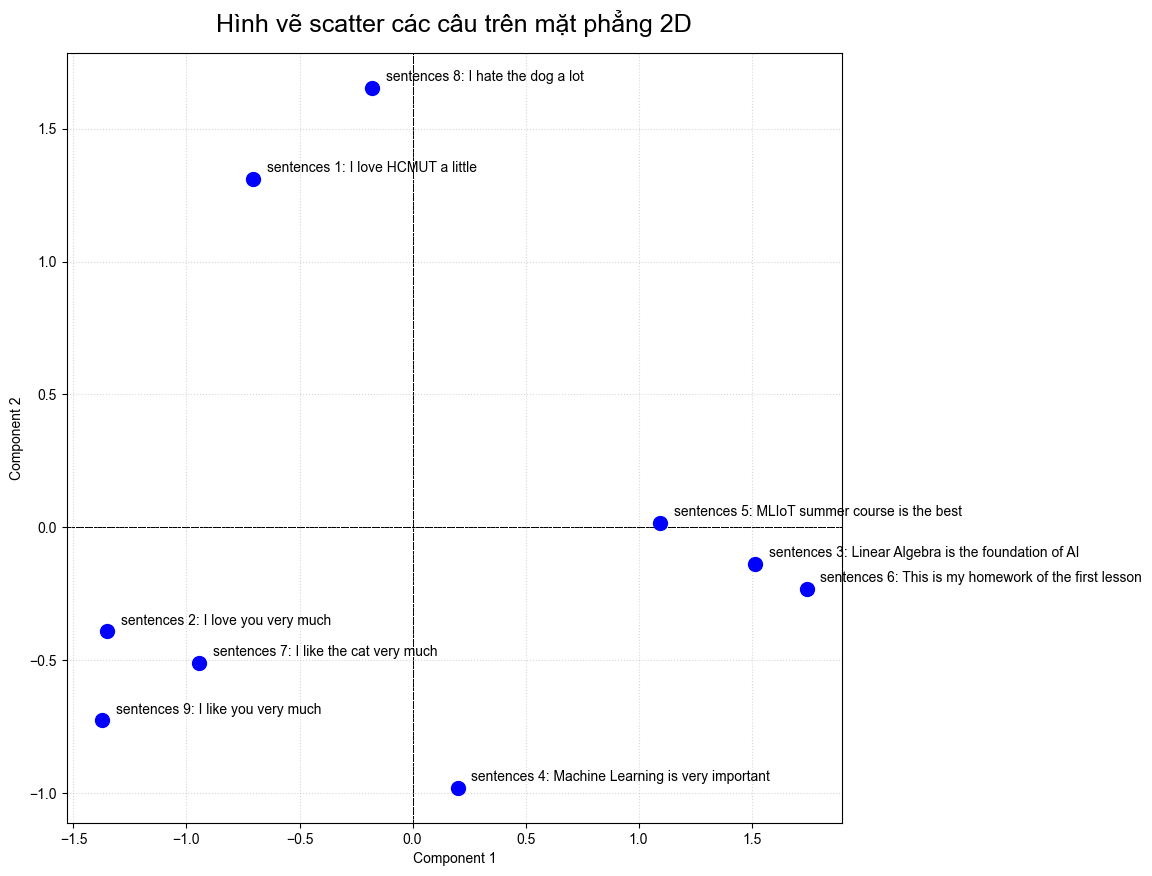

In [5]:
import matplotlib.pyplot as plt
Xc = X - X.mean(axis =0) # center du lieu
U, S, Vt = np.linalg.svd(Xc , full_matrices=False)
coords = U[:, :2] * S[:2] #tọa độ 2D của câu
print("Kích thước ban đầu:",X.shape)
print("Kích thước giảm về 2D:", coords.shape)
plt.figure(figsize=(10,10))
plt.rcParams['font.family'] = 'Arial'
plt.scatter(coords[:,0], coords[:,1], color= 'blue', s = 100, zorder = 10)
for idx, text in enumerate(sentences):
    plt.annotate(f"sentences {idx+1}: {text}",(coords[idx,0], coords[idx,1]), textcoords="offset points", xytext=(10,5), ha='left', fontsize = 10) #gắn tên cho từng tọa độ
    plt.axhline(0, color='black', linestyle='--', linewidth=0.6)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.6)
    plt.title("Hình vẽ scatter các câu trên mặt phẳng 2D", fontsize=18,pad=15)
    plt.xlabel("Component 1", fontsize=10)
    plt.ylabel("Component 2", fontsize=10)
    plt.grid(True, linestyle=":", alpha=0.5)
plt.show()



Ta nhận thấy các câu có cấu trúc tương đồng hoặc nội dung giống nhau(về AI, Linear Algebra) sẽ nằm gần nhau còn các câu không liên quan sẽ cách xe nhau. Từ đây ta có thể nói SVD giảm chiều của dữ liệu(PCA) nhưng vẫn giữ lại các trục chính và tính chính xác cũng như chứa nhiều thông tin nhất của dữ liệu. Điều này giống như các eigen vector của các giá trị kì dị lớn nhất giúp lượt bỏ đi các chiều không cần thiết.